# Teste de Atalho (Shortcut Test) — BUS-BRA

## Objetivo
Verificar se o dataset BUSBRA contém **viés espúrio** que permitiria a um 
classificador distinguir benigno de maligno **sem olhar a lesão**.

> "Se der acima do acaso, o dataset tem viés espúrio e tudo precisa ser 
> reinterpretado. Em ultrassom clínico, calipers e anotações são um risco 
> real (se aparecerem mais em malignos, o modelo acerta sem olhar a lesão). 
> Rodar na Semana 1." — Plano de Execução, Seção 7

## O que são atalhos em ultrassom?
- **Calipers** (+): marcadores de medição sobrepostos pelo operador
- **Anotações textuais**: "QSE", "MAMA ESQUERDA", localização anatômica
- **Medidas**: "13.2mm", "8.2MM" — dimensões do nódulo (!)
- **Logo/marca do equipamento**: "GE" e variantes
- **Indicadores de profundidade**: números nas laterais
- **Dimensões da imagem**: tamanhos diferentes por aparelho

## Estratégia
1. Criar imagens que contêm **apenas** informação não-clínica (artefatos)
2. Treinar um classificador ResNet-50 nessas imagens
3. Se AUC > 0.5 + margem → viés espúrio confirmado

## Três abordagens complementares de extração:
- **Bordas**: faixa periférica da imagem (texto, escala, logo)
- **Artefatos brilhantes**: calipers e sobreposições (outliers locais)
- **Combinado**: bordas + artefatos brilhantes

In [13]:
import os
import numpy as np
import pandas as pd
from PIL import Image
import cv2
from scipy.ndimage import uniform_filter, distance_transform_edt, grey_opening, binary_dilation
import matplotlib
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm

# ==============================================================================
# CONFIGURAÇÕES
# ==============================================================================

BASE_DIR = Path('.')
BUSBRA_DIR = BASE_DIR / 'BUSBRA' / 'BUSBRA'
IMAGES_DIR = BUSBRA_DIR / 'Images'
MASKS_DIR = BUSBRA_DIR / 'Masks'
CSV_PATH = BUSBRA_DIR / 'bus_data.csv'
OUTPUT_DIR = BASE_DIR / 'processed' / 'shortcut_test'

# Parâmetros de extração de artefatos
BORDER_WIDTH = 40        # Largura da faixa periférica (px)

# Parâmetros do White Top-Hat Transform para detecção de artefatos
# O top-hat (original - opening morfológica) isola estruturas brilhantes
# menores que o kernel, como texto, calipers e marcações sobrepostas.
# Usa-se esse método em vez de outlier local porque:
#   - Texto sobre fundo claro infla a média local e escapa da detecção
#   - O top-hat captura qualquer estrutura fina brilhante independente do fundo
TOPHAT_KERNEL_SIZE = 21   # Tamanho do kernel de abertura morfológica (px)
TOPHAT_THRESHOLD = 100    # Limiar mínimo na resposta do top-hat (0-255)
                          # Valor alto (100) para pegar só artefatos artificiais,
                          # não textura de tecido (ondas ecogênicas)
ARTIFACT_MIN_INTENSITY = 200  # Intensidade absoluta mínima (0-255)
                              # Artefatos sobrepostos são quase brancos (>200)

# Exclusão peri-lesional: dilatação da máscara para excluir halo ecogênico
# O halo brilhante ao redor de nódulos escuros gera falsos positivos no top-hat.
# Dilatamos a máscara GT em 30px para excluir essa região de transição,
# garantindo que só capturamos artefatos DISTANTES da lesão.
PERILESIONAL_DILATION = 30  # Raio de exclusão peri-lesional (px)

print(f"Images: {IMAGES_DIR}")
print(f"Output: {OUTPUT_DIR}")

Images: BUSBRA/BUSBRA/Images
Output: processed/shortcut_test


In [19]:
# ==============================================================================
# CARREGAMENTO DO CATÁLOGO
# ==============================================================================

df = pd.read_csv(CSV_PATH)

# Catálogo
catalog = {}
for _, row in df.iterrows():
    img_id = row['ID']
    img_path = IMAGES_DIR / f"{img_id}.png"
    mask_path = MASKS_DIR / f"mask_{img_id[4:]}.png"
    
    if img_path.exists() and mask_path.exists():
        catalog[img_id] = {
            'image_path': img_path,
            'mask_path': mask_path,
            'pathology': row['Pathology'],
            'fold': row['K5B'],
            'birads': row['BIRADS'],
            'device': row['Device'],
            'width': row['Width'],
            'height': row['Height'],
        }

print(f"Catálogo: {len(catalog)} imagens")
print(f"Benignas: {sum(1 for v in catalog.values() if v['pathology']=='benign')}")
print(f"Malignas: {sum(1 for v in catalog.values() if v['pathology']=='malignant')}")

Catálogo: 1875 imagens
Benignas: 1268
Malignas: 607


## Análise Preliminar de Viés

Antes de treinar modelos, vamos verificar se existem correlações óbvias 
entre features não-clínicas e a classe patológica. Se houver, já é um 
indicativo de que o teste de atalho pode dar positivo.

In [20]:
# ==============================================================================
# ANÁLISE PRELIMINAR: CORRELAÇÃO FEATURES NÃO-CLÍNICAS × CLASSE
# ==============================================================================

results = []

for img_id, info in tqdm(catalog.items(), desc="Analisando artefatos"):
    img = np.array(Image.open(info['image_path'])).astype(np.float64)
    h, w = img.shape
    
    # Features de artefatos
    bright_pct = (img > 230).sum() / img.size * 100
    border_mean = np.mean([
        img[:5, :].mean(), img[-5:, :].mean(),
        img[:, :5].mean(), img[:, -5:].mean()
    ])
    
    results.append({
        'ID': img_id,
        'pathology': info['pathology'],
        'device': info['device'],
        'birads': info['birads'],
        'width': w,
        'height': h,
        'aspect_ratio': w / h,
        'bright_pct': bright_pct,
        'border_mean': border_mean,
        'img_mean': img.mean(),
        'img_std': img.std(),
    })

rdf = pd.DataFrame(results)

# Comparação por classe
print("=" * 60)
print("FEATURES NÃO-CLÍNICAS: BENIGNO vs MALIGNO")
print("=" * 60)

features = ['width', 'height', 'aspect_ratio', 'bright_pct', 
            'border_mean', 'img_mean', 'img_std']

for feat in features:
    benign = rdf[rdf['pathology'] == 'benign'][feat]
    malign = rdf[rdf['pathology'] == 'malignant'][feat]
    
    # Teste Mann-Whitney U (não-paramétrico)
    from scipy.stats import mannwhitneyu
    stat, pval = mannwhitneyu(benign, malign, alternative='two-sided')
    
    sig = "⚠️" if pval < 0.05 else "✅"
    print(f"\n{sig} {feat}:")
    print(f"   Benigno: {benign.mean():.2f} ± {benign.std():.2f}")
    print(f"   Maligno: {malign.mean():.2f} ± {malign.std():.2f}")
    print(f"   Mann-Whitney p={pval:.4f}")

# Distribuição de dispositivos por classe
print("\n" + "=" * 60)
print("DISTRIBUIÇÃO DE DISPOSITIVOS POR CLASSE")
print("=" * 60)

ct = pd.crosstab(rdf['pathology'], rdf['device'])
print(ct)
print()
ct_pct = pd.crosstab(rdf['pathology'], rdf['device'], normalize='index') * 100
print("Percentual por classe:")
print(ct_pct.round(1))

# Teste qui-quadrado
from scipy.stats import chi2_contingency
chi2, p_chi2, dof, expected = chi2_contingency(ct)
print(f"\nTeste χ²: χ²={chi2:.2f}, p={p_chi2:.4f}, dof={dof}")
if p_chi2 < 0.05:
    print("⚠️ Distribuição de dispositivos DIFERE significativamente entre classes!")
    print("   Isso é um risco: o modelo pode aprender a identificar o aparelho.")
else:
    print("✅ Distribuição de dispositivos similar entre classes.")

Analisando artefatos: 100%|██████████| 1875/1875 [00:07<00:00, 262.39it/s]


FEATURES NÃO-CLÍNICAS: BENIGNO vs MALIGNO

✅ width:
   Benigno: 323.47 ± 80.57
   Maligno: 316.79 ± 68.50
   Mann-Whitney p=0.5903

✅ height:
   Benigno: 392.84 ± 53.04
   Maligno: 387.94 ± 52.42
   Mann-Whitney p=0.1279

✅ aspect_ratio:
   Benigno: 0.82 ± 0.15
   Maligno: 0.82 ± 0.15
   Mann-Whitney p=0.9436

✅ bright_pct:
   Benigno: 1.42 ± 2.37
   Maligno: 1.30 ± 2.34
   Mann-Whitney p=0.1705

✅ border_mean:
   Benigno: 83.22 ± 26.12
   Maligno: 84.16 ± 28.07
   Mann-Whitney p=0.6545

✅ img_mean:
   Benigno: 83.83 ± 28.16
   Maligno: 81.57 ± 29.78
   Mann-Whitney p=0.0564

⚠️ img_std:
   Benigno: 40.28 ± 11.89
   Maligno: 38.25 ± 11.50
   Mann-Whitney p=0.0006

DISTRIBUIÇÃO DE DISPOSITIVOS POR CLASSE
device     GE Logiq 5 @10-12MHz  GE Logiq 7 @10-14MHz  \
pathology                                               
benign                      566                   617   
malignant                   243                   285   

device     Toshiba Aplio 300 @12-14 MHz  U-Systems @10-14M

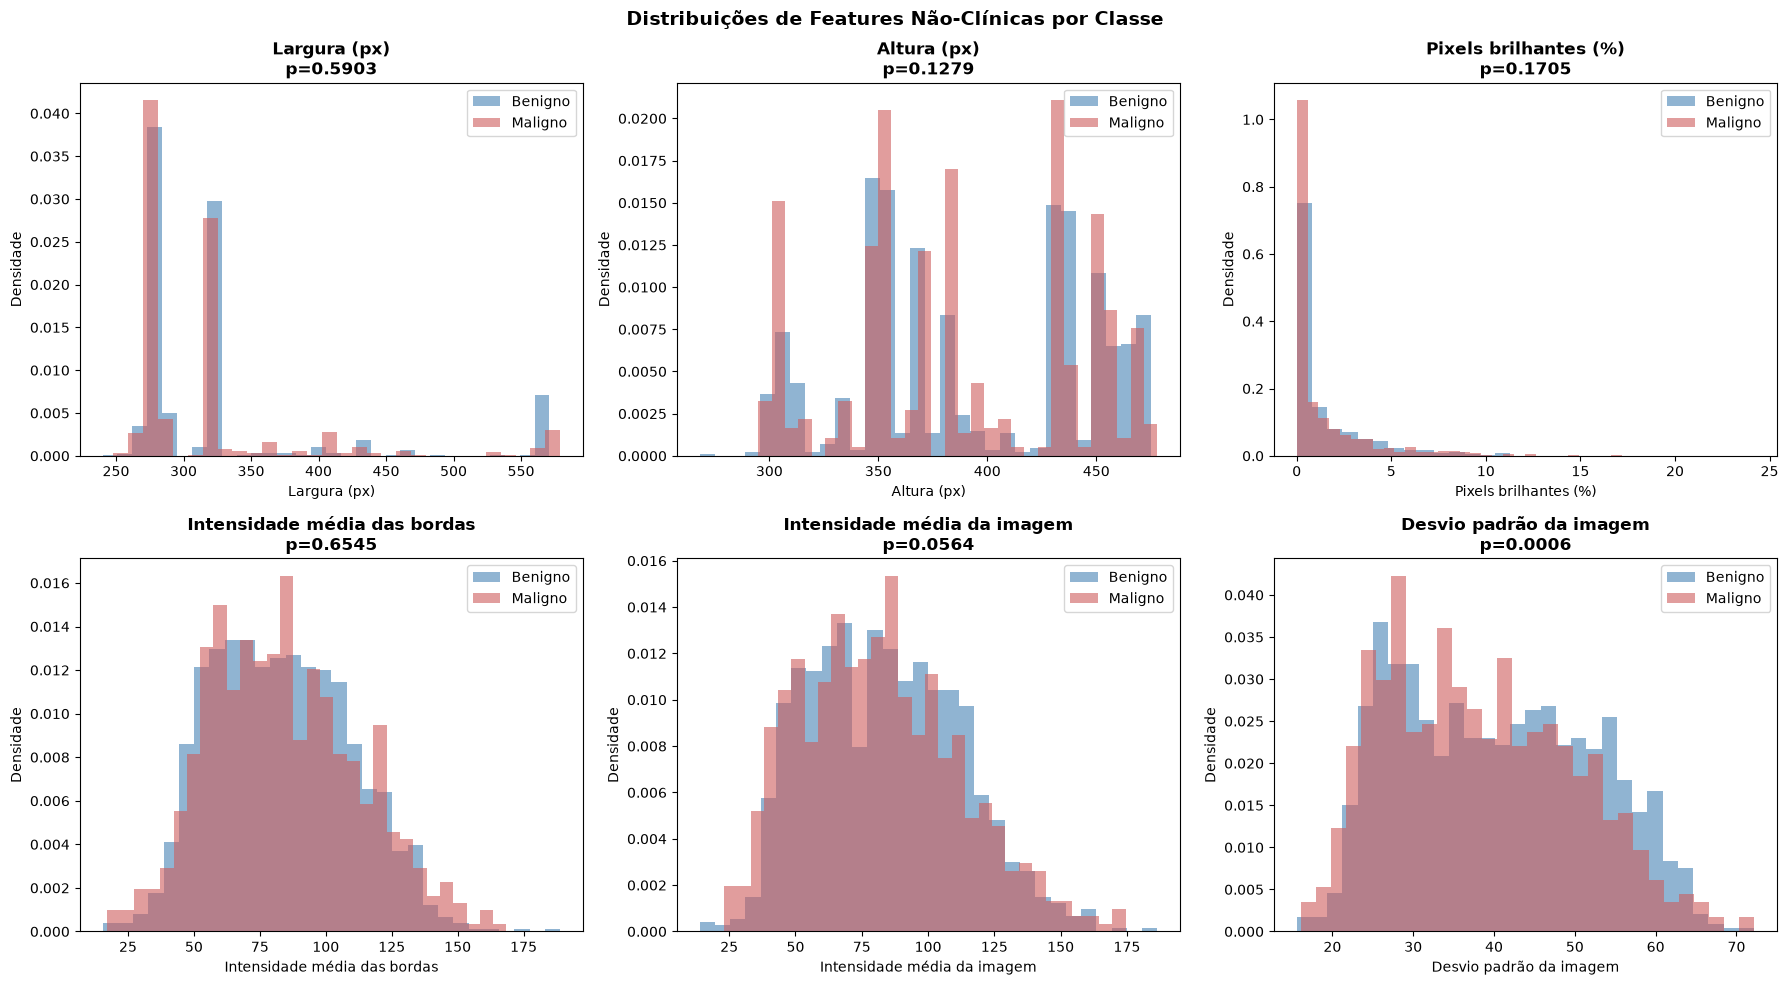

Salvo: processed/shortcut_test/feature_distributions.png


In [21]:
# ==============================================================================
# VISUALIZAÇÃO: DISTRIBUIÇÕES POR CLASSE
# ==============================================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

features_to_plot = [
    ('width', 'Largura (px)'),
    ('height', 'Altura (px)'),
    ('bright_pct', 'Pixels brilhantes (%)'),
    ('border_mean', 'Intensidade média das bordas'),
    ('img_mean', 'Intensidade média da imagem'),
    ('img_std', 'Desvio padrão da imagem'),
]

for idx, (feat, label) in enumerate(features_to_plot):
    ax = axes[idx // 3, idx % 3]
    
    benign = rdf[rdf['pathology'] == 'benign'][feat]
    malign = rdf[rdf['pathology'] == 'malignant'][feat]
    
    ax.hist(benign, bins=30, alpha=0.6, label='Benigno', color='steelblue', density=True)
    ax.hist(malign, bins=30, alpha=0.6, label='Maligno', color='indianred', density=True)
    ax.set_xlabel(label)
    ax.set_ylabel('Densidade')
    ax.legend()
    
    from scipy.stats import mannwhitneyu
    _, pval = mannwhitneyu(benign, malign, alternative='two-sided')
    ax.set_title(f'{label}\np={pval:.4f}', fontweight='bold')

plt.suptitle('Distribuições de Features Não-Clínicas por Classe', fontsize=14, fontweight='bold')
plt.tight_layout()

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(OUTPUT_DIR / 'feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Salvo: {OUTPUT_DIR / 'feature_distributions.png'}")

## Extração de Imagens de Atalho

Três modos de extração complementares:

### 1. `border_only` — Faixa periférica
Mantém apenas os N pixels nas bordas da imagem. Captura:
- Texto de anotação (QSE, MAMA ESQUERDA, etc.)
- Indicadores de profundidade/escala
- Logo do equipamento

### 2. `artifacts_only` — White Top-Hat Transform
Usa transformada morfológica top-hat (original - opening) para isolar 
estruturas brilhantes finas sobrepostas à imagem. Captura:
- Calipers (+) — marcadores de medição
- Texto sobreposto em qualquer posição (não só bordas)
- Medidas numéricas (13.2mm, etc.)

> **Por que não outlier local?** O método anterior (pixel > média_local + 2.5σ) 
> falhava quando texto brilhante ficava sobre fundo claro: o texto inflava 
> a própria média local e escapava da detecção. O top-hat é invariante ao 
> nível de fundo — ele captura qualquer estrutura fina, independente de 
> quão brilhante é a vizinhança.

### 3. `combined` — Bordas + artefatos
União dos dois modos anteriores. Maximiza a captura de informação espúria.

> [!IMPORTANT]
> Em todos os modos, a região da LESÃO é explicitamente apagada (usando a 
> máscara GT invertida) para garantir que nenhuma informação clínica real 
> contamine o teste. Caso contrário, o teste não mediria atalhos.

In [22]:
# ==============================================================================
# FUNÇÕES DE EXTRAÇÃO DE ARTEFATOS
# ==============================================================================

def _get_dilated_mask(mask, dilation_radius=PERILESIONAL_DILATION):
    """
    Dilata a máscara da lesão para excluir a região peri-lesional.
    
    O halo ecogênico ao redor de nódulos (especialmente hipoecóicos) 
    gera falsos positivos no top-hat. Dilatando a máscara, excluímos
    essa região de transição e focamos apenas em artefatos distantes.
    
    Args:
        mask:             np.ndarray bool — máscara binária da lesão
        dilation_radius:  int — raio de dilatação em pixels
    
    Returns:
        np.ndarray bool — máscara dilatada
    """
    struct = np.ones((3, 3))
    return binary_dilation(mask, structure=struct, iterations=dilation_radius)


def extract_border_only(image, mask, border_width=BORDER_WIDTH,
                        dilation_radius=PERILESIONAL_DILATION):
    """
    Extrai apenas a faixa periférica da imagem.
    
    Mantém os 'border_width' pixels nas 4 bordas da imagem. O restante
    (incluindo a lesão e região peri-lesional) é zerado. 
    Captura: texto, escala, logo, indicadores de profundidade.
    
    Args:
        image:            np.ndarray float64 [0,1], shape (H, W)
        mask:             np.ndarray bool — máscara da lesão
        border_width:     int — largura da faixa periférica em pixels
        dilation_radius:  int — raio de exclusão peri-lesional
        
    Returns:
        np.ndarray float64 [0,1] — imagem apenas com bordas
    """
    h, w = image.shape
    result = np.zeros_like(image)
    
    # Manter faixa periférica
    result[:border_width, :] = image[:border_width, :]    # topo
    result[-border_width:, :] = image[-border_width:, :]  # base
    result[:, :border_width] = image[:, :border_width]    # esquerda
    result[:, -border_width:] = image[:, -border_width:]  # direita
    
    # Apagar lesão + região peri-lesional
    mask_dilated = _get_dilated_mask(mask, dilation_radius)
    result[mask_dilated] = 0
    
    return result


def extract_artifacts_only(image, mask, kernel_size=TOPHAT_KERNEL_SIZE,
                           tophat_thresh=TOPHAT_THRESHOLD,
                           min_intensity=ARTIFACT_MIN_INTENSITY,
                           dilation_radius=PERILESIONAL_DILATION):
    """
    Extrai artefatos sobrepostos (calipers, texto, medidas) usando 
    White Top-Hat Transform com exclusão peri-lesional.
    
    O top-hat morfológico (original - opening) isola estruturas brilhantes
    menores que o kernel de abertura. Captura:
    - Calipers (+): marcadores de medição finos e brilhantes
    - Texto sobreposto: "QSE", "MAMA ESQUERDA", "13.2mm"
    - Qualquer marcação pontual do operador
    
    Três filtros são aplicados:
    1. tophat_thresh=100: resposta do top-hat forte (estrutura realmente
       se destaca, não é textura contínua de tecido)
    2. min_intensity=200: apenas pixels quase brancos (artefatos são 
       sobrepostos com intensidade máxima pelo aparelho)
    3. Exclusão peri-lesional: remove o halo ecogênico ao redor de 
       nódulos que seria falso positivo
    
    Args:
        image:            np.ndarray float64 [0,1], shape (H, W)
        mask:             np.ndarray bool — máscara da lesão
        kernel_size:      int — kernel de abertura morfológica
        tophat_thresh:    float — limiar no top-hat (0-255)
        min_intensity:    float — intensidade mínima absoluta (0-255)
        dilation_radius:  int — raio de exclusão peri-lesional
        
    Returns:
        np.ndarray float64 [0,1] — imagem apenas com artefatos detectados
    """
    # Converter para escala 0-255 para operações morfológicas
    img_255 = (image * 255.0).astype(np.float64)
    
    # White Top-Hat: original - opening
    opened = grey_opening(img_255, size=(kernel_size, kernel_size))
    tophat = np.clip(img_255 - opened, 0, 255)
    
    # Máscara de exclusão: lesão + região peri-lesional
    mask_dilated = _get_dilated_mask(mask, dilation_radius)
    
    # Detecção de artefatos (3 critérios)
    artifact_mask = (tophat > tophat_thresh) & (img_255 > min_intensity) & ~mask_dilated
    
    result = np.zeros_like(image)
    result[artifact_mask] = image[artifact_mask]
    
    return result


def extract_combined(image, mask, border_width=BORDER_WIDTH,
                     kernel_size=TOPHAT_KERNEL_SIZE,
                     tophat_thresh=TOPHAT_THRESHOLD,
                     min_intensity=ARTIFACT_MIN_INTENSITY,
                     dilation_radius=PERILESIONAL_DILATION):
    """
    Combina bordas + artefatos (White Top-Hat) com exclusão peri-lesional.
    
    União dos dois modos de extração. É a versão mais conservadora:
    se nem isso classificar acima do acaso, o dataset está limpo.
    
    Args:
        image:            np.ndarray float64 [0,1]
        mask:             np.ndarray bool
        border_width:     int
        kernel_size:      int
        tophat_thresh:    float
        min_intensity:    float
        dilation_radius:  int
        
    Returns:
        np.ndarray float64 [0,1]
    """
    borders = extract_border_only(image, mask, border_width, dilation_radius)
    artifacts = extract_artifacts_only(image, mask, kernel_size, tophat_thresh,
                                       min_intensity, dilation_radius)
    
    # União: pixel máximo entre os dois
    result = np.maximum(borders, artifacts)
    
    return result


# Modos disponíveis
SHORTCUT_MODES = {
    'border_only': extract_border_only,
    'artifacts_only': extract_artifacts_only,
    'combined': extract_combined,
}

print("Funções de extração de atalhos definidas.")
print(f"  Método: White Top-Hat + exclusão peri-lesional")
print(f"  Top-Hat: kernel={TOPHAT_KERNEL_SIZE}, thresh={TOPHAT_THRESHOLD}, min_intensity={ARTIFACT_MIN_INTENSITY}")
print(f"  Exclusão peri-lesional: {PERILESIONAL_DILATION}px")
print(f"  Modos: {list(SHORTCUT_MODES.keys())}")

Funções de extração de atalhos definidas.
  Método: White Top-Hat + exclusão peri-lesional
  Top-Hat: kernel=21, thresh=100, min_intensity=200
  Exclusão peri-lesional: 30px
  Modos: ['border_only', 'artifacts_only', 'combined']


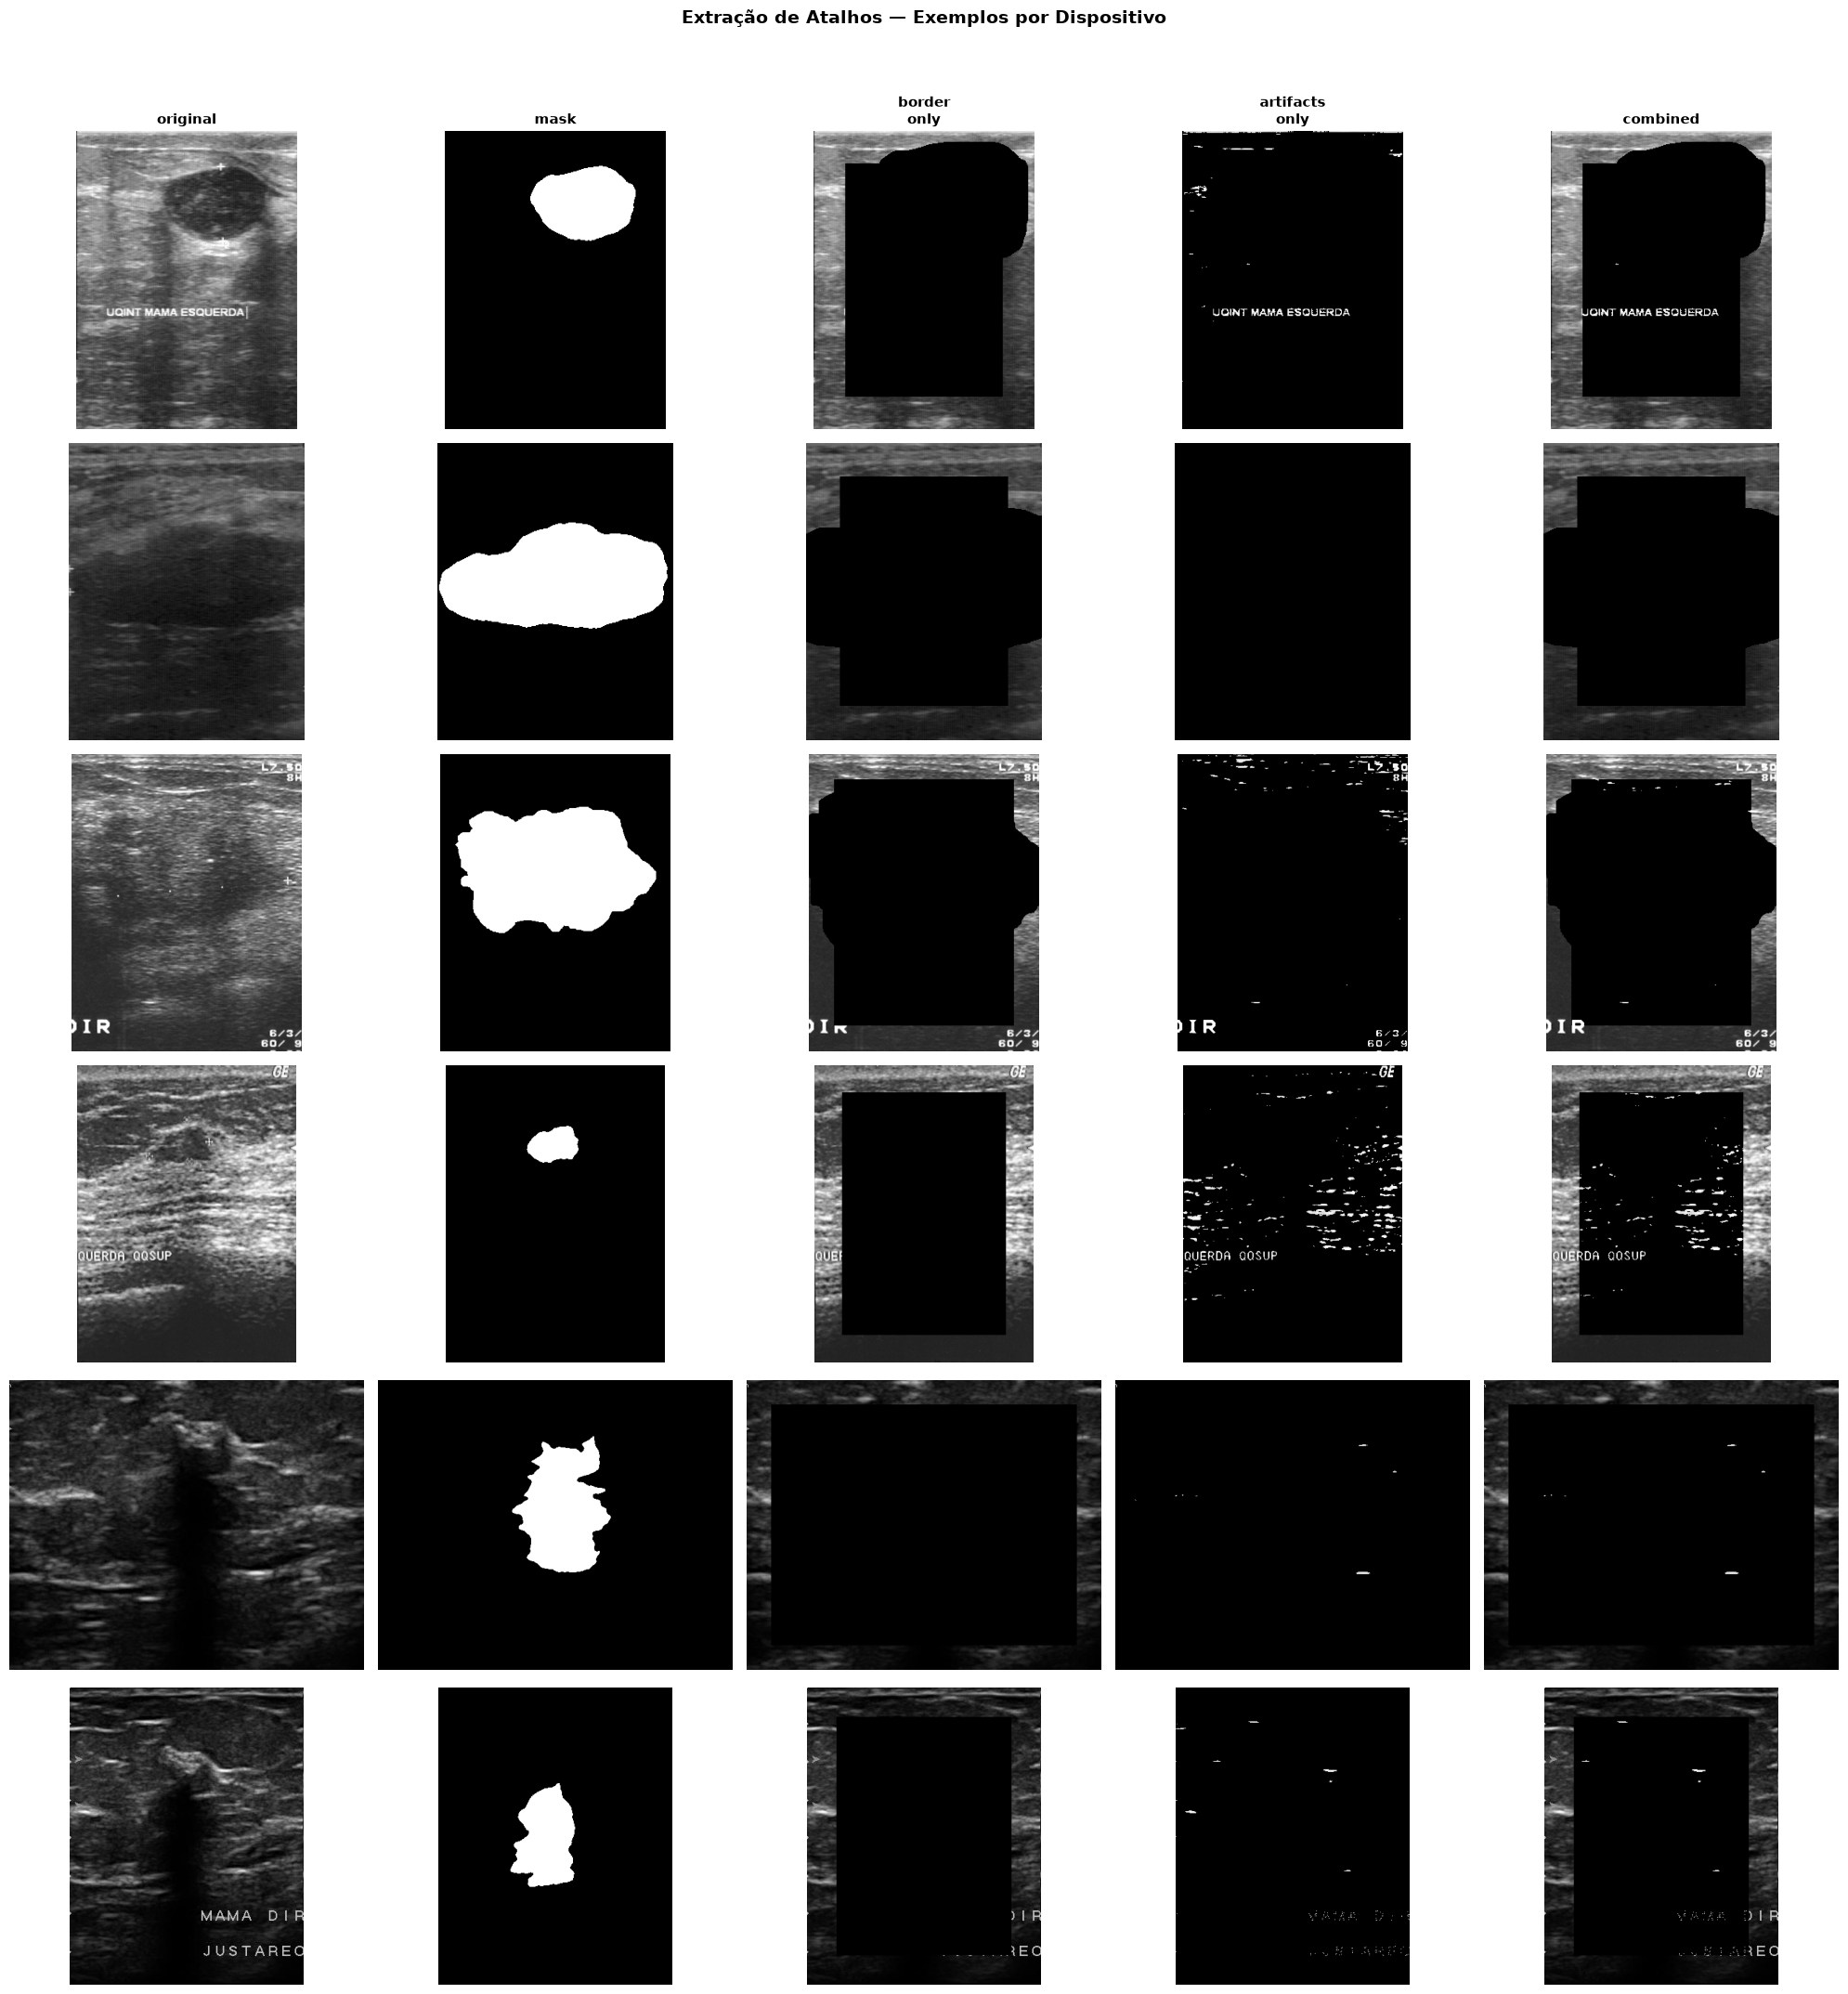

Salvo: processed/shortcut_test/shortcut_extraction_examples.png


In [23]:
# ==============================================================================
# VISUALIZAÇÃO: EXEMPLOS DE EXTRAÇÃO DE ATALHOS
# ==============================================================================

np.random.seed(42)

# Selecionar amostras variadas (diferentes dispositivos e classes)
sample_ids = []
for device in df['Device'].unique():
    device_ids = [k for k, v in catalog.items() if v['device'] == device]
    if len(device_ids) >= 2:
        sample_ids.extend(np.random.choice(device_ids, 2, replace=False))
    else:
        sample_ids.extend(device_ids)

# Limitar a 6 exemplos
sample_ids = sample_ids[:6]

modes = ['original', 'mask', 'border_only', 'artifacts_only', 'combined']
n_rows = len(sample_ids)
n_cols = len(modes)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3.5 * n_rows))
if n_rows == 1:
    axes = axes[np.newaxis, :]

for row_idx, img_id in enumerate(sample_ids):
    info = catalog[img_id]
    
    # Carregar imagem e máscara
    image = np.array(Image.open(info['image_path']).convert('L')).astype(np.float64) / 255.0
    mask = np.array(Image.open(info['mask_path']).convert('1')).astype(bool)
    
    for col_idx, mode in enumerate(modes):
        ax = axes[row_idx, col_idx]
        
        if mode == 'original':
            ax.imshow(image, cmap='gray', vmin=0, vmax=1)
        elif mode == 'mask':
            ax.imshow(mask, cmap='gray')
        elif mode in SHORTCUT_MODES:
            result = SHORTCUT_MODES[mode](image, mask)
            ax.imshow(result, cmap='gray', vmin=0, vmax=1)
        
        ax.axis('off')
        
        if row_idx == 0:
            ax.set_title(mode.replace('_', '\n'), fontsize=11, fontweight='bold')
        
        if col_idx == 0:
            label = f"{img_id}\n{info['pathology']}\n{info['device'][:12]}"
            ax.set_ylabel(label, fontsize=8, rotation=0, labelpad=90)

plt.suptitle('Extração de Atalhos — Exemplos por Dispositivo', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'shortcut_extraction_examples.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Salvo: {OUTPUT_DIR / 'shortcut_extraction_examples.png'}")

In [ ]:
# ==============================================================================
# PROCESSAMENTO EM LOTE — GERAR IMAGENS DE ATALHO
# ==============================================================================

def process_shortcut_images(catalog, modes=SHORTCUT_MODES, output_dir=OUTPUT_DIR):
    """
    Gera imagens de atalho para todos os modos e todas as imagens.
    
    Estrutura de saída:
        shortcut_test/
        ├── border_only/
        │   └── bus_XXXX-Y.png
        ├── artifacts_only/
        │   └── bus_XXXX-Y.png
        └── combined/
            └── bus_XXXX-Y.png
    """
    output_dir = Path(output_dir)
    
    # Criar diretórios
    for mode in modes:
        (output_dir / mode).mkdir(parents=True, exist_ok=True)
    
    print(f"Processando {len(catalog)} imagens × {len(modes)} modos...")
    
    for img_id, info in tqdm(catalog.items(), desc="Gerando atalhos"):
        # Carregar uma vez
        image = np.array(Image.open(info['image_path']).convert('L')).astype(np.float64) / 255.0
        mask = np.array(Image.open(info['mask_path']).convert('1')).astype(bool)
        
        for mode_name, extract_fn in modes.items():
            out_path = output_dir / mode_name / f"{img_id}.png"
            
            if out_path.exists():
                continue
            
            result = extract_fn(image, mask)
            
            # Salvar como uint8
            img_uint8 = (result * 255).clip(0, 255).astype(np.uint8)
            Image.fromarray(img_uint8, mode='L').save(out_path)
    
    print(f"\nProcessamento concluído! Salvo em: {output_dir}")

# Executar processamento
process_shortcut_images(catalog)

## Treinamento do Classificador de Atalho

Treinamos uma **ResNet-50 pré-treinada (ImageNet)** nas imagens de atalho, 
usando os **5 folds oficiais** do BUSBRA e **3 seeds por fold**.

### Protocolo
- Mesmo protocolo do pipeline principal (Seção 8 do plano)
- Métrica: AUC-ROC
- **Resultado esperado**: AUC próximo de 0.5 (acaso)
- **Resultado preocupante**: AUC > 0.55 com significância estatística

### Interpretação
| AUC | Interpretação | Ação |
|---|---|---|
| ~0.50 | Sem viés | ✅ Prosseguir com confiança |
| 0.50–0.55 | Viés marginal | ⚠️ Monitorar, reportar no artigo |
| 0.55–0.60 | Viés moderado | ⚠️ Investigar causa, considerar mitigação |
| >0.60 | Viés forte | 🚨 Parar e reinterpretar TUDO |

In [ ]:
# ==============================================================================
# DATASET PYTORCH PARA TESTE DE ATALHO
# ==============================================================================

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import roc_auc_score

class ShortcutDataset(Dataset):
    """
    Dataset PyTorch para imagens de atalho.
    
    Carrega imagens de um diretório de atalho (border_only, artifacts_only,
    ou combined) e retorna (imagem, label) onde label é 0=benigno, 1=maligno.
    
    As imagens são redimensionadas para 224×224 (canvas fixo, armadilha #4).
    A normalização usa os parâmetros do ImageNet para compatibilidade com
    a ResNet-50 pré-treinada.
    """
    
    def __init__(self, img_ids, catalog, shortcut_dir, transform=None):
        self.img_ids = img_ids
        self.catalog = catalog
        self.shortcut_dir = Path(shortcut_dir)
        self.transform = transform
        
        # Mapeamento de labels
        self.label_map = {'benign': 0, 'malignant': 1}
    
    def __len__(self):
        return len(self.img_ids)
    
    def __getitem__(self, idx):
        img_id = self.img_ids[idx]
        info = self.catalog[img_id]
        
        # Carregar imagem de atalho
        img_path = self.shortcut_dir / f"{img_id}.png"
        image = Image.open(img_path).convert('RGB')  # 3 canais para ResNet
        
        if self.transform:
            image = self.transform(image)
        
        label = self.label_map[info['pathology']]
        return image, label


# Transforms para treino e validação
# Resize 224×224 com canvas fixo (armadilha #4)
# Normalização ImageNet para ResNet pré-treinada
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),  # augmentation mínimo
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225]),
])

print("Dataset e transforms definidos.")

In [ ]:
# ==============================================================================
# TREINAMENTO E AVALIAÇÃO — TESTE DE ATALHO
# ==============================================================================

def train_shortcut_classifier(catalog, shortcut_dir, n_folds=5, seeds=[42, 123, 456],
                              n_epochs=15, batch_size=32, lr=1e-4, device_name=None):
    """
    Treina e avalia um classificador ResNet-50 em imagens de atalho.
    
    Usa os 5 folds oficiais do BUSBRA (coluna K5B) e 3 seeds por fold.
    
    Args:
        catalog:      dict — catálogo de imagens
        shortcut_dir: Path — diretório com imagens de atalho
        n_folds:      int — número de folds (5 oficiais)
        seeds:        list — seeds para reprodutibilidade
        n_epochs:     int — épocas de treinamento
        batch_size:   int — tamanho do batch
        lr:           float — learning rate
        device_name:  str — 'cuda' ou 'cpu'
        
    Returns:
        dict com AUCs por fold × seed
    """
    if device_name is None:
        device_name = 'cuda' if torch.cuda.is_available() else 'cpu'
    device = torch.device(device_name)
    print(f"Usando dispositivo: {device}")
    
    # Organizar IDs por fold
    fold_ids = {}
    for img_id, info in catalog.items():
        fold = info['fold']
        if fold not in fold_ids:
            fold_ids[fold] = []
        fold_ids[fold].append(img_id)
    
    # Calcular class weights para compensar desbalanceamento
    n_benign = sum(1 for v in catalog.values() if v['pathology'] == 'benign')
    n_malign = sum(1 for v in catalog.values() if v['pathology'] == 'malignant')
    # Peso inversamente proporcional à frequência
    weight_benign = len(catalog) / (2 * n_benign)
    weight_malign = len(catalog) / (2 * n_malign)
    class_weights = torch.tensor([weight_benign, weight_malign], dtype=torch.float32).to(device)
    print(f"Class weights: benign={weight_benign:.3f}, malignant={weight_malign:.3f}")
    
    all_results = []
    
    for fold_val in range(1, n_folds + 1):
        for seed in seeds:
            print(f"\n{'='*50}")
            print(f"Fold {fold_val}/5, Seed {seed}")
            print(f"{'='*50}")
            
            # Fixar seed
            torch.manual_seed(seed)
            np.random.seed(seed)
            
            # Split: fold_val é validação, o resto é treino
            train_ids = []
            val_ids = fold_ids[fold_val]
            for f in range(1, n_folds + 1):
                if f != fold_val:
                    train_ids.extend(fold_ids[f])
            
            print(f"  Treino: {len(train_ids)}, Validação: {len(val_ids)}")
            
            # Datasets
            train_dataset = ShortcutDataset(train_ids, catalog, shortcut_dir, train_transform)
            val_dataset = ShortcutDataset(val_ids, catalog, shortcut_dir, val_transform)
            
            train_loader = DataLoader(train_dataset, batch_size=batch_size, 
                                     shuffle=True, num_workers=2)
            val_loader = DataLoader(val_dataset, batch_size=batch_size,
                                   shuffle=False, num_workers=2)
            
            # Modelo: ResNet-50 pré-treinada, última camada adaptada
            model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
            model.fc = nn.Linear(model.fc.in_features, 2)
            model = model.to(device)
            
            # Loss com class weights
            criterion = nn.CrossEntropyLoss(weight=class_weights)
            optimizer = optim.Adam(model.parameters(), lr=lr)
            
            # Treinamento
            best_auc = 0
            for epoch in range(n_epochs):
                model.train()
                train_loss = 0
                for images, labels in train_loader:
                    images, labels = images.to(device), labels.to(device)
                    
                    optimizer.zero_grad()
                    outputs = model(images)
                    loss = criterion(outputs, labels)
                    loss.backward()
                    optimizer.step()
                    
                    train_loss += loss.item()
                
                # Validação
                model.eval()
                all_probs = []
                all_labels = []
                
                with torch.no_grad():
                    for images, labels in val_loader:
                        images, labels = images.to(device), labels.to(device)
                        outputs = model(images)
                        probs = torch.softmax(outputs, dim=1)[:, 1]  # prob de maligno
                        
                        all_probs.extend(probs.cpu().numpy())
                        all_labels.extend(labels.cpu().numpy())
                
                auc = roc_auc_score(all_labels, all_probs)
                if auc > best_auc:
                    best_auc = auc
                
                if (epoch + 1) % 5 == 0 or epoch == 0:
                    print(f"  Epoch {epoch+1}/{n_epochs} | "
                          f"Loss: {train_loss/len(train_loader):.4f} | "
                          f"AUC: {auc:.4f}")
            
            print(f"  → Melhor AUC: {best_auc:.4f}")
            
            all_results.append({
                'fold': fold_val,
                'seed': seed,
                'best_auc': best_auc,
            })
    
    return all_results


# NÃO executar automaticamente — é computacionalmente caro
print("Função de treinamento definida.")
print("Execute a célula seguinte para rodar o teste de atalho.")

In [ ]:
# ==============================================================================
# EXECUÇÃO DO TESTE DE ATALHO
# ==============================================================================
# Descomente o modo desejado e execute.
# Recomendação: começar com 'combined' (mais conservador).

shortcut_mode = 'combined'  # 'border_only', 'artifacts_only', ou 'combined'
shortcut_dir = OUTPUT_DIR / shortcut_mode

print(f"Executando teste de atalho com modo: {shortcut_mode}")
print(f"Diretório: {shortcut_dir}")
print(f"Imagens disponíveis: {len(list(shortcut_dir.glob('*.png')))}") 

results = train_shortcut_classifier(
    catalog=catalog,
    shortcut_dir=shortcut_dir,
    n_folds=5,
    seeds=[42, 123, 456],
    n_epochs=15,
    batch_size=32,
    lr=1e-4,
)

# Converter para DataFrame
results_df = pd.DataFrame(results)
print("\n" + "=" * 60)
print(f"RESULTADOS — Teste de Atalho ({shortcut_mode})")
print("=" * 60)
print(results_df.to_string(index=False))
print(f"\nAUC média: {results_df['best_auc'].mean():.4f} ± {results_df['best_auc'].std():.4f}")
print(f"AUC mediana: {results_df['best_auc'].median():.4f}")

# Interpretar resultado
mean_auc = results_df['best_auc'].mean()
if mean_auc < 0.52:
    print("\n✅ AUC próximo do acaso — SEM viés espúrio detectado.")
elif mean_auc < 0.55:
    print("\n⚠️ AUC levemente acima do acaso — viés MARGINAL. Monitorar e reportar.")
elif mean_auc < 0.60:
    print("\n⚠️ AUC moderadamente acima do acaso — viés MODERADO. Investigar causa.")
else:
    print("\n🚨 AUC significativamente acima do acaso — viés FORTE! Reinterpretar resultados.")

In [ ]:
# ==============================================================================
# VISUALIZAÇÃO DOS RESULTADOS
# ==============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: AUC por fold
ax1 = axes[0]
folds = sorted(results_df['fold'].unique())
for fold in folds:
    fold_aucs = results_df[results_df['fold'] == fold]['best_auc']
    ax1.scatter([fold] * len(fold_aucs), fold_aucs, alpha=0.7, s=60)
    ax1.hlines(fold_aucs.mean(), fold - 0.2, fold + 0.2, colors='red', linewidth=2)

ax1.axhline(y=0.5, color='gray', linestyle='--', linewidth=1, label='Acaso (0.5)')
ax1.axhline(y=results_df['best_auc'].mean(), color='red', linestyle='-', 
            linewidth=1.5, alpha=0.7, label=f'Média ({results_df["best_auc"].mean():.3f})')
ax1.set_xlabel('Fold')
ax1.set_ylabel('AUC-ROC')
ax1.set_title(f'AUC por Fold — Teste de Atalho ({shortcut_mode})', fontweight='bold')
ax1.legend()
ax1.set_ylim(0.35, 0.75)

# Plot 2: Distribuição geral
ax2 = axes[1]
ax2.hist(results_df['best_auc'], bins=8, alpha=0.7, color='steelblue', edgecolor='black')
ax2.axvline(x=0.5, color='gray', linestyle='--', linewidth=1.5, label='Acaso (0.5)')
ax2.axvline(x=results_df['best_auc'].mean(), color='red', linestyle='-', 
            linewidth=2, label=f'Média ({results_df["best_auc"].mean():.3f})')
ax2.set_xlabel('AUC-ROC')
ax2.set_ylabel('Contagem')
ax2.set_title('Distribuição de AUC — Todos os Runs', fontweight='bold')
ax2.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / f'shortcut_results_{shortcut_mode}.png', dpi=150, bbox_inches='tight')
plt.show()

# Teste estatístico: AUC significativamente diferente de 0.5?
from scipy.stats import wilcoxon
aucs = results_df['best_auc'].values
# Teste contra 0.5
stat, pval = wilcoxon(aucs - 0.5, alternative='greater')
print(f"\nTeste de Wilcoxon (AUC > 0.5): p={pval:.4f}")
if pval < 0.05:
    print("⚠️ AUC é estatisticamente significativamente ACIMA do acaso!")
else:
    print("✅ Não há evidência estatística de AUC acima do acaso.")

## Próximos Passos

### Se o teste for NEGATIVO (AUC ≈ 0.5):
✅ Prosseguir com a grade de masking. O dataset não tem viés espúrio 
detectável por este teste.

### Se o teste for POSITIVO (AUC > 0.55):
1. Investigar **qual modo** (border/artifacts/combined) contribui mais
2. Verificar se o viés vem de um **dispositivo específico**
3. Considerar **pré-processamento de limpeza**: remover bordas, igualar 
   dimensões, apagar calipers
4. Reportar o resultado no artigo — transparência é fundamental
5. Re-rodar toda a grade de masking após mitigação

### Controles adicionais (Seção 7 do plano):
- **Context-only**: apagar lesão, manter entorno → implementar depois
- **Máscara deslocada**: verificar se ganho vem da localização correta